In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# First, let's define four colors to work with (which will be stored numerically as an index)
colors = [0, 10, 60, 90]

# Method for displaying an image after converting color indices to colors.
def show_im(im, ax=None):
    temp_im = np.array(im, dtype=np.uint8)
    for i in range(len(colors)):
        temp_im[temp_im == i] = colors[i]
    if ax == None:
        plt.imshow(temp_im, cmap='terrain', vmin=0, vmax=255)
    else:
        ax.imshow(temp_im, cmap='terrain', vmin=0, vmax=255)

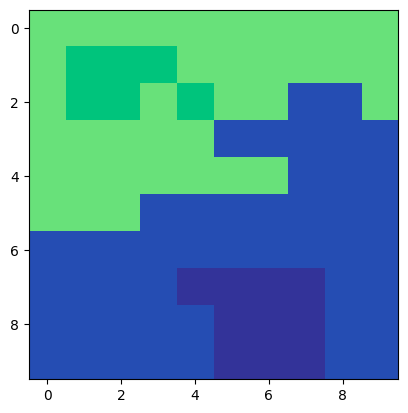

In [4]:
tilemap = np.ones((10,10))

tilemap[0:2, :] = 3
tilemap[2:3, :7] = 3
tilemap[3:5, :5] = 3
tilemap[4, 5:7] = 3
tilemap[5, :3] = 3
tilemap[2, -1] = 3

tilemap[1:3, 1:3] = 2
tilemap[1, 3] = 2
tilemap[2,4] = 2

tilemap[7, 4:8] = 0
tilemap[8:10, 5:8] = 0

show_im(tilemap)

In [5]:
# Collect tiles
tilemap_size = 10
n = 2

tiles = np.zeros((tilemap_size - n + 1, tilemap_size - n + 1, n, n))

for i in range(tilemap_size - n + 1):
    for j in range(tilemap_size - n + 1):
        tiles[i, j] = tilemap[i:i+n, j:j+n]

In [6]:
def hash_tile(tile):
    return int(tile[0,0] + 4 * tile[0, 1] + 16 * tile[1, 0] + 64 * tile[1,1])

def reverse_hash(num):
    tile = np.zeros(4)
    n = num
    for i in range(len(tile)):
        tile[i] = n % 4
        n = n // 4
    return tile.reshape((2,2))
    

# Gather unique tiles and record frequency (frequency will be weight the superposition collapse)
tile_set = {}
l = tilemap_size - n + 1

for i in range(l):
    for j in range(l):
        val = hash_tile(tiles[i,j])

        if val not in tile_set.keys():
            tile_set[val] = 1
        else:
            tile_set[val] += 1

In [7]:
# We need a way to compare borders. Ima keep using this hash
def compare_tile_ar(tile1, tile2, t1_border, t2_border):
    assert len(t1_border) == len(t2_border), "Border Sizes Must Match"

    h1 = hash_tile(tile1)
    h2 = hash_tile(tile2)

    for i in range(len(t1_border)):
        if (h1 // 4**t1_border[i]) % 4 != (h2 // 4**t2_border[i]) % 4:
            return False
    return True

In [8]:
t1 = reverse_hash(95)
t2 = reverse_hash(85)

print(compare_tile_ar(t1, t2, [0, 1], [0, 1]))
print(compare_tile_ar(t1, t2, [2, 3], [2, 3]))

False
True


In [9]:
def compare_hashes(h1, h2, t1_border, t2_border):
    assert len(t1_border) == len(t2_border), "Border Sizes Must Match"

    for i in range(len(t1_border)):
        if (h1 // 4**t1_border[i]) % 4 != (h2 // 4**t2_border[i]) % 4:
            return False
    return True

# Now let's make adjacency rules!
# Each adjacency is designated by a (tile hash, direction) key
# So (850, 'tr') stores pieces that can connect with the top right of 850
directions =     ['t',  'tr', 'tl', 'r', 'l',    'b', 'br', 'bl']
t1_comparisons = [[0,1], [1], [0], [1,3], [0,2], [2,3], [3], [2]]
t2_comparisons = [[2,3], [2], [3], [0,2], [1,3], [0,1], [0], [1]]
adjacencies = {}

for t in tile_set.keys():
    # t is the current tile to compute adjacencies for
    # adjacencies[(t, 't')] = []
    for d in range(len(directions)):
        adjacencies[(t, directions[d])] = []

    for target in tile_set.keys():
        if t == target:
            continue # Avoid checking adjacencies against yourself

        for d in range(len(directions)):
            if compare_hashes(t, target, t1_comparisons[d], t2_comparisons[d]) and target not in adjacencies[(t, directions[d])]:
                adjacencies[(t, directions[d])].append(target)

In [10]:
adjacencies

{(191, 't'): [255, 251, 250, 254, 247, 245],
 (191, 'tr'): [255, 187, 190, 127, 251, 250, 254, 126, 247, 245, 117],
 (191, 'tl'): [239, 255, 234, 223, 251, 250, 254, 247, 245],
 (191, 'r'): [175, 239],
 (191, 'l'): [239, 255, 223, 254],
 (191, 'b'): [187, 251],
 (191, 'br'): [170, 234, 190, 250, 254, 126],
 (191, 'bl'): [175, 239, 255, 190, 127, 95, 223, 254, 126, 93],
 (175, 't'): [255, 251, 250, 254, 247, 245],
 (175, 'tr'): [191, 255, 187, 190, 127, 251, 250, 254, 126, 247, 245, 117],
 (175, 'tl'): [239, 255, 234, 223, 251, 250, 254, 247, 245],
 (175, 'r'): [239],
 (175, 'l'): [191, 190],
 (175, 'b'): [170, 234, 250],
 (175, 'br'): [170, 234, 190, 250, 254, 126],
 (175, 'bl'): [187, 170, 234, 251, 250],
 (239, 't'): [255, 251, 250, 254, 247, 245],
 (239, 'tr'): [191, 255, 187, 190, 127, 251, 250, 254, 126, 247, 245, 117],
 (239, 'tl'): [255, 234, 223, 251, 250, 254, 247, 245],
 (239, 'r'): [191, 255, 187, 127, 251, 247],
 (239, 'l'): [191, 175, 190],
 (239, 'b'): [190, 254, 126],
 (

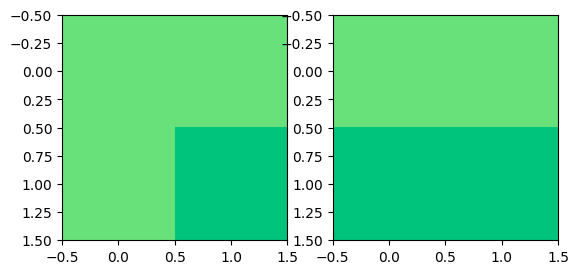

In [11]:
fig, ax = plt.subplots(1, 2)
show_im(reverse_hash(191), ax[0])
show_im(reverse_hash(175), ax[1])

In [12]:
# max_tile_weight = sum(tile_set.values())
# tile_weights = np.array(tile_set.values())

# Bad intersection code for temporary work...
def intersect(a1, a2):
    dest = []

    for a in a1:
        if a in a2:
            dest.append(a)

    return dest

directions = ['t', 'tr', 'tl', 'r', 'l', 'b', 'br', 'bl']
dir_steps = [(-1, 0), (-1, 1), (-1, -1), (0, 1), (0, -1), (1, 0), (1, 1), (1, -1)]

class Cell:

    def __init__(self, row=0, col=0):
        self.superposition = list(tile_set.keys())
        self.weights = list(tile_set.values())
        self.state = -1

        self.row = row
        self.col = col
    
    def collapse(self, propagation_queue):
        total_weight = sum(self.weights)

        choice = np.random.choice(int(len(self.superposition)), p=np.array(self.weights)/total_weight)
        self.state = self.superposition[choice]

        for i in range(len(directions)):
            step = dir_steps[i]

            # To the propagation queue, we add the cell's location and then its allowed states based on
            # what the cell collapsed to.
            propagation_queue.append([(self.row + step[0], self.col + step[1]), adjacencies[(self.state, directions[i])]])
    
    def narrow(self, possibilities):
        if self.state != -1:
            # We have already collapsed the superposition...
            return

        new_superposition = intersect(self.superposition, possibilities)
        new_weights = []

        # Intersect weights as well as states
        for i in range(len(new_superposition)):
            for j in range(len(self.superposition)):
                if new_superposition[i] == self.superposition[j]:
                    new_weights.append(self.weights[j])

        self.superposition = new_superposition
        self.weights = new_weights
    
    def entropy(self):
        if self.state != -1:
            return 100000
        else:
            return len(self.superposition)
        


c = Cell()
# print(c.superposition)
# print(c.weights)
q = []
c.collapse(q)
print(q)

[[(-1, 0), [191, 190]], [(-1, 1), [175, 239, 170, 234]], [(-1, -1), [239, 255, 234, 223, 251, 250, 254, 247, 245]], [(0, 1), [170, 234]], [(0, -1), [239, 255, 223, 254]], [(1, 0), [251]], [(1, 1), [170, 234, 190, 250, 254, 126]], [(1, -1), [191, 175, 239, 255, 190, 127, 95, 223, 254, 126, 93]]]


In [13]:
c.weights[16]

24

In [14]:
# Let's attempt generation of a small grid
grid = np.zeros((4,4))
cell_space = [ [Cell(i,j) for i in range (3)] for j in range(3)]

queue = []
cell_space[0][0].collapse(queue)

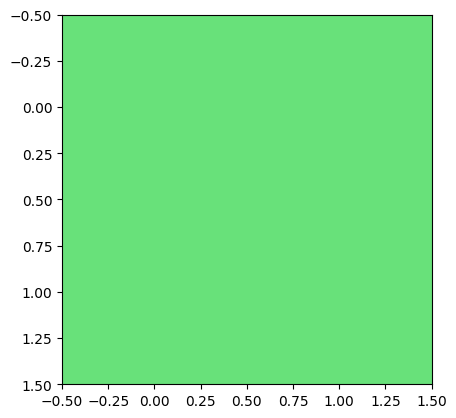

In [15]:
show_im(reverse_hash(cell_space[0][0].state))

In [16]:
queue

[[(-1, 0), [251, 250, 254, 247, 245]],
 [(-1, 1), [191, 187, 190, 127, 251, 250, 254, 126, 247, 245, 117]],
 [(-1, -1), [239, 234, 223, 251, 250, 254, 247, 245]],
 [(0, 1), [191, 187, 127, 251, 247]],
 [(0, -1), [239, 223, 254]],
 [(1, 0), [191, 175, 239, 127, 95, 223]],
 [(1, 1), [191, 175, 239, 187, 127, 95, 223, 251, 87, 247]],
 [(1, -1), [191, 175, 239, 190, 127, 95, 223, 254, 126, 93]]]

In [17]:
for q in queue:
    pos = q[0]

    if pos[0] < 0 or pos[0] > 2 or pos[1] < 0 or pos[1] > 2:
        continue  # Skip if out-of-bounds

    pos = q[0]
    possibilities = q[1]

    cell_space[pos[0]][pos[1]].narrow(possibilities)

In [18]:
entropy_grid = np.zeros((3,3))

for i in range(3):
    for j in range(3):
        entropy_grid[i,j] = cell_space[i][j].entropy()

entropy_grid

array([[1.0e+05, 5.0e+00, 2.9e+01],
       [6.0e+00, 1.0e+01, 2.9e+01],
       [2.9e+01, 2.9e+01, 2.9e+01]])

In [19]:
np.argmin(entropy_grid.flatten())

np.int64(1)

In [20]:
np.min(entropy_grid)

np.float64(5.0)

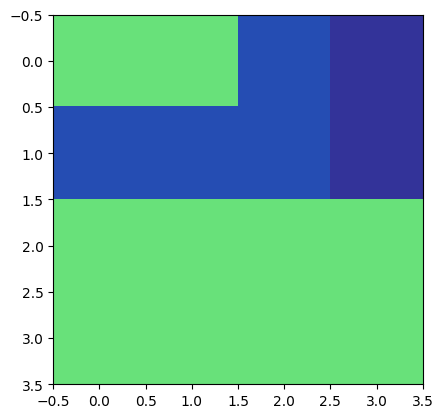

In [301]:
# Let's attempt generation of a small grid
attempts_allowed = 100
grid_size = 4

for i in range(attempts_allowed):
    try:
        cell_space = [ [Cell(i,j) for i in range (grid_size-1)] for j in range(grid_size-1)]
        entropy_grid = np.zeros((grid_size-1,grid_size-1))

        for i in range(grid_size-1):
            for j in range(grid_size-1):
                entropy_grid[i,j] = cell_space[i][j].entropy()

        while np.min(entropy_grid) < 1000:
            # Get row and column of minimum entropy
            row, col = np.unravel_index(np.argmin(entropy_grid), entropy_grid.shape)

            queue = []
            cell_space[row][col].collapse(queue)

            # Narrow possibilities based on collapse
            for q in queue:
                pos = q[0]

                if pos[0] < 0 or pos[0] > grid_size-2 or pos[1] < 0 or pos[1] > grid_size-2:
                    continue  # Skip if out-of-bounds

                possibilities = q[1]
                cell_space[pos[0]][pos[1]].narrow(possibilities)

            for i in range(grid_size-1):
                for j in range(grid_size-1):
                    entropy_grid[i,j] = cell_space[i][j].entropy()
        
        break
    except:
        pass

# Time to build the grid with the cell states
grid = np.zeros((grid_size,grid_size))
for i in range(grid_size//2):
    for j in range(grid_size//2):
        grid[i*2:(i+1)*2, j*2:(j+1)*2] = reverse_hash(cell_space[2*i][2*j].state)
show_im(grid)

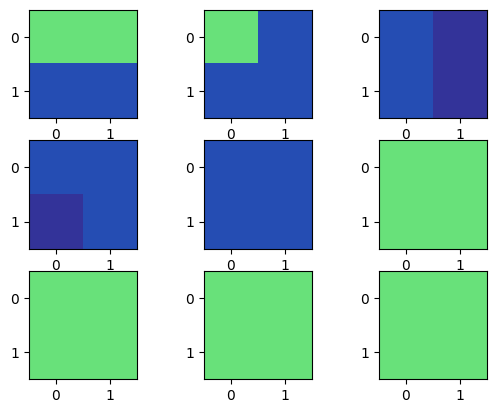

In [302]:
fig, ax = plt.subplots(3, 3)
show_im(reverse_hash(cell_space[0][0].state), ax[0,0])
show_im(reverse_hash(cell_space[0][1].state), ax[0,1])
show_im(reverse_hash(cell_space[0][2].state), ax[0,2])

show_im(reverse_hash(cell_space[1][0].state), ax[1,0])
show_im(reverse_hash(cell_space[1][1].state), ax[1,1])
show_im(reverse_hash(cell_space[1][2].state), ax[1,2])

show_im(reverse_hash(cell_space[2][0].state), ax[2,0])
show_im(reverse_hash(cell_space[2][1].state), ax[2,1])
show_im(reverse_hash(cell_space[2][2].state), ax[2,2])

In [297]:
cell_space[0][0].state

117

In [298]:
cell_space[1][0].state

87

In [299]:
for i in range(len(cell_space)):
    s = ""

    for j in range(len(cell_space[0])):
        s += str(cell_space[i][j].state) + " "

    print(s)

117 85 -1 
87 21 5 
-1 -1 -1 


In [300]:
entropy_grid

array([[1.e+05, 1.e+05, 4.e+00],
       [1.e+05, 1.e+05, 1.e+05],
       [0.e+00, 2.e+00, 0.e+00]])